In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

import lightgbm as lgb
import catboost as cb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

## 1. Загрузка данных

In [2]:
train = pd.read_csv('shift_ml_2026_train.csv', low_memory=False)
test = pd.read_csv('shift_ml_2026_test.csv', low_memory=False)

TARGET = 'итоговый_статус_займа'
ID_COL = 'id'

y = train[TARGET].values
train_ids = train[ID_COL].values
test_ids = test[ID_COL].values

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print(f"\nTarget: '{TARGET}'")
print(f"Positive rate: {y.mean():.4f} ({y.sum()} / {len(y)})")

Train shape: (1210779, 109)
Test  shape: (134531, 108)

Target: 'итоговый_статус_займа'
Positive rate: 0.1996 (241694 / 1210779)


## Структура данных и целевая переменная

- Обучающая выборка содержит **1 210 779** наблюдений и **109** признаков, включая целевую переменную.
- Тестовая выборка содержит **134 531** наблюдение и **108** признаков, что подтверждает корректность структуры данных 
- Целевая переменная `итоговый_статус_займа` является бинарной:
  - `1` - займ не выплачен (дефолт),
  - `0` - займ выплачен.

  Доля положительного класса (дефолта) составляет примерно **20%**, что указывает на умеренный дисбаланс классов.

## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=" * 60)
print("ТИПЫ ДАННЫХ")
print("=" * 60)
print(train.dtypes.value_counts())
print()

cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in [ID_COL, TARGET]]

print(f"Числовых признаков: {len(num_cols)}")
print(f"Категориальных признаков: {len(cat_cols)}")
print()

print("=" * 60)
print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ")
print("=" * 60)
for c in cat_cols:
    nuniq = train[c].nunique()
    nulls_pct = train[c].isnull().mean() * 100
    sample = train[c].dropna().unique()[:5]
    print(f"  {c}: unique={nuniq}, nulls={nulls_pct:.1f}%, sample={sample}")

ТИПЫ ДАННЫХ
float64    84
object     19
int64       6
Name: count, dtype: int64

Числовых признаков: 88
Категориальных признаков: 19

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
  срок_займа: unique=2, nulls=0.0%, sample=['3 года' '5 лет']
  рейтинг: unique=7, nulls=0.0%, sample=['В' 'Б' 'А' 'Д' 'Г']
  допрейтинг: unique=35, nulls=0.0%, sample=['В1' 'Б4' 'В3' 'Б2' 'Б1']
  профессия_заемщика: unique=273666, nulls=6.4%, sample=['инженер' 'водитель грузовика' 'ветеринарный техник'
 'вице-президент операций по набору персонала' 'дорожному водителю']
  стаж: unique=11, nulls=5.8%, sample=['10+ лет' '4 года' '6 лет' '3 года' '7 лет']
  владение_жильем: unique=6, nulls=0.0%, sample=['ИПОТЕКА' 'АРЕНДА' 'СОБСТВЕННОСТЬ' 'ЛЮБОЕ' 'НЕТ']
  подтвержден_ли_доход: unique=3, nulls=0.0%, sample=['Не подтвержден' 'Подтвержден источник' 'Подтвержден']
  платежный_график: unique=1, nulls=0.0%, sample=['n']
  цель_займа: unique=14, nulls=0.0%, sample=['мелкий_бизнес' 'улучшение_жилищных_условий' 'консолидация_долга'
 'крупная_

## Типы признаков и их распределение

В датасете присутствуют:
- **88 числовых признаков** (`int`, `float`);
- **19 категориальных признаков** (`object`).


## Анализ категориальных признаков

Категориальные признаки существенно различаются по своей природе и количеству уникальных значений:

- Часть признаков имеет **низкую кардинальность** (2-7 уникальных значений), например:
  - `срок_займа`,
  - `рейтинг`,
  - `тип_займа`,
  - `юридический_статус`.

- Некоторые признаки имеют **среднюю кардинальность** (десятки значений), например:
  - `допрейтинг`,
  - `цель_займа`,
  - `регион`.

- Отдельные признаки обладают **очень высокой кардинальностью**, например:
  - `профессия_заемщика` (более 270 тыс. уникальных значений).


## Пропуски в категориальных признаках

В ряде категориальных признаков наблюдается значительная доля пропущенных значений:
- `пени_за_дефолт` - около 30% пропусков;
- `совокупный_статус_подтверждения_доходов_заемщиков` - более 98% пропусков.

Подобные признаки могут быть:
- либо малоинформативными,
- либо сигнализировать о специфических сегментах клиентов.

В дальнейшем пропуски не удалялись, так как используемые модели (LightGBM, CatBoost) способны корректно обрабатывать `NaN` и учитывать сам факт отсутствия значения.

## Влияние структуры данных на выбор моделей

Результаты анализа типов признаков и их кардинальности повлияли на дальнейшие архитектурные решения:

- **LightGBM** был выбран как основная модель благодаря высокой эффективности на больших табличных датасетах.
- **CatBoost** использовался как альтернативная модель, устойчиво работающая с категориальными признаками, включая признаки с высокой кардинальностью.
- Использование one-hot кодирования было сознательно ограничено из-за большого числа уникальных категорий в отдельных признаках.

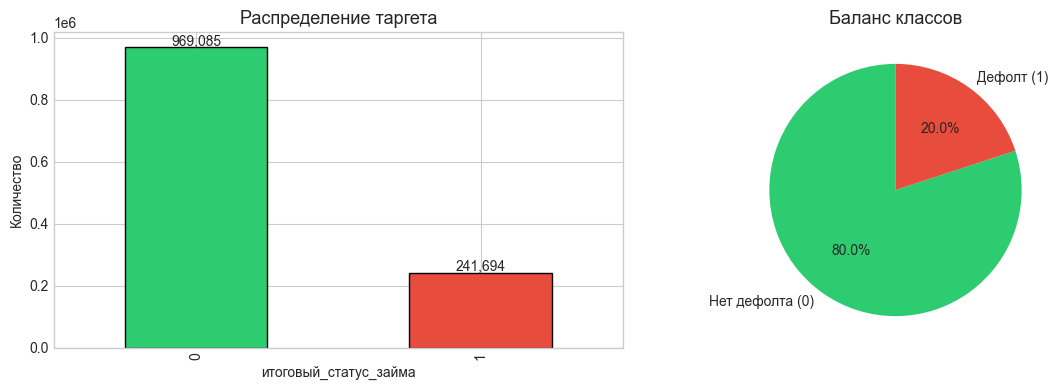


Дисбаланс классов: 1:4 (позитивных ≈ 20.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train[TARGET].value_counts()
counts.plot.bar(ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Распределение таргета', fontsize=13)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

counts.plot.pie(ax=axes[1], autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'],
                labels=['Нет дефолта (0)', 'Дефолт (1)'],
                startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Баланс классов', fontsize=13)

plt.tight_layout()
plt.show()

print(f"\nДисбаланс классов: 1:{int(counts.values[0] / counts.values[1])} (позитивных ≈ {y.mean()*100:.1f}%)")

## Следствия для выбора моделей и обучения

Выявленный дисбаланс классов был учтен на этапе моделирования:

- использовалась стратифицированная кросс-валидация (Stratified K-Fold);
- модели обучались на вероятностный прогноз (predict_proba), а не на жесткую классификацию;
- не применялось агрессивное oversampling/undersampling, так как выбранные бустинговые модели эффективно работают с подобным уровнем дисбаланса.


Признаков с пропусками: 69 из 109
Признаков без пропусков: 40



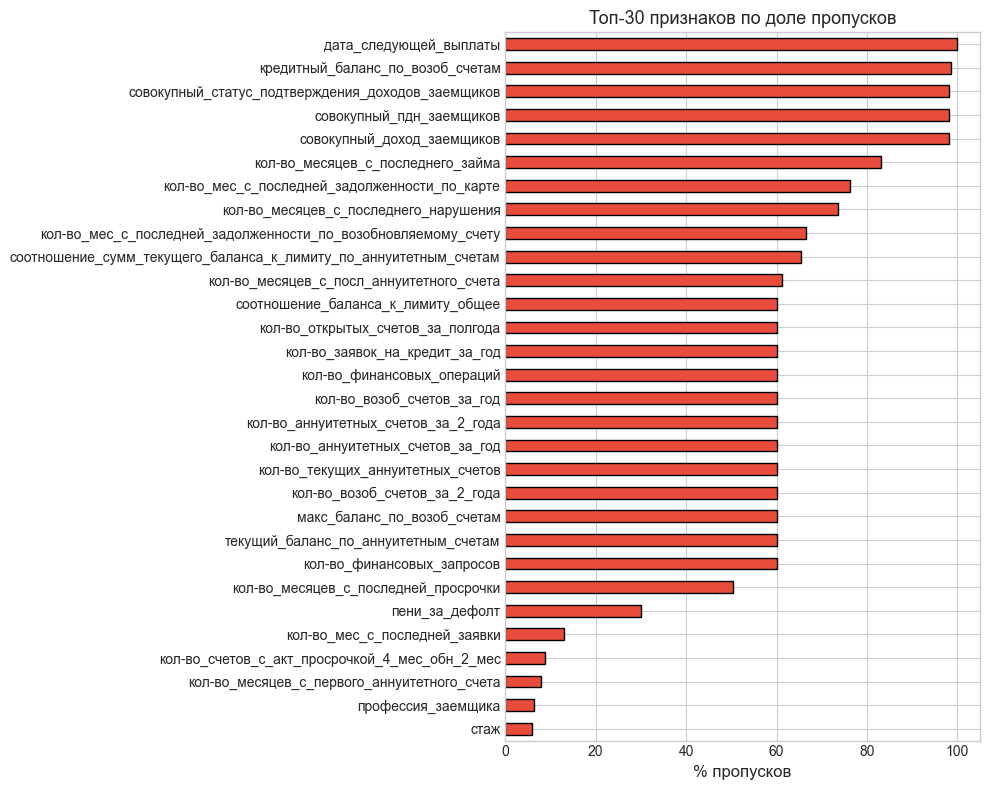

In [5]:
nulls_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
nulls_pct_pos = nulls_pct[nulls_pct > 0]

print(f"Признаков с пропусками: {len(nulls_pct_pos)} из {train.shape[1]}")
print(f"Признаков без пропусков: {(nulls_pct == 0).sum()}")
print()

fig, ax = plt.subplots(figsize=(10, 8))
nulls_pct_pos.head(30).plot.barh(ax=ax, color='#e74c3c', edgecolor='black')
ax.set_xlabel('% пропусков', fontsize=12)
ax.set_title('Топ-30 признаков по доле пропусков', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Анализ пропусков в данных

В ходе анализа было выявлено, что пропуски присутствуют в значительной части признаков:

- **69 признаков из 109** содержат пропущенные значения;
- **40 признаков** заполнены полностью.



## Структура пропусков

На графике представлены **30 признаков с наибольшей долей пропусков**. Можно выделить несколько характерных групп:

- признаки, связанные с **кредитной историей и активностью счетов**;
- агрегированные показатели по займам и счетам;
- временные признаки (даты, количество месяцев с последнего события).

В ряде признаков доля пропусков превышает **60–90%**, что указывает на их применимость только к определённым сегментам клиентов.

## Интерпретация пропусков

Пропуски в кредитных данных не обязательно означают низкое качество данных.  
Часто отсутствие значения отражает **отсутствие соответствующего события или продукта**, к примеру:
- отсутствие предыдущих займов,
- отсутствие кредитной карты или аннуитетного счёта,
- отсутствие просрочек в истории.

Факт наличия или отсутствия значения сам по себе может быть информативным признаком.

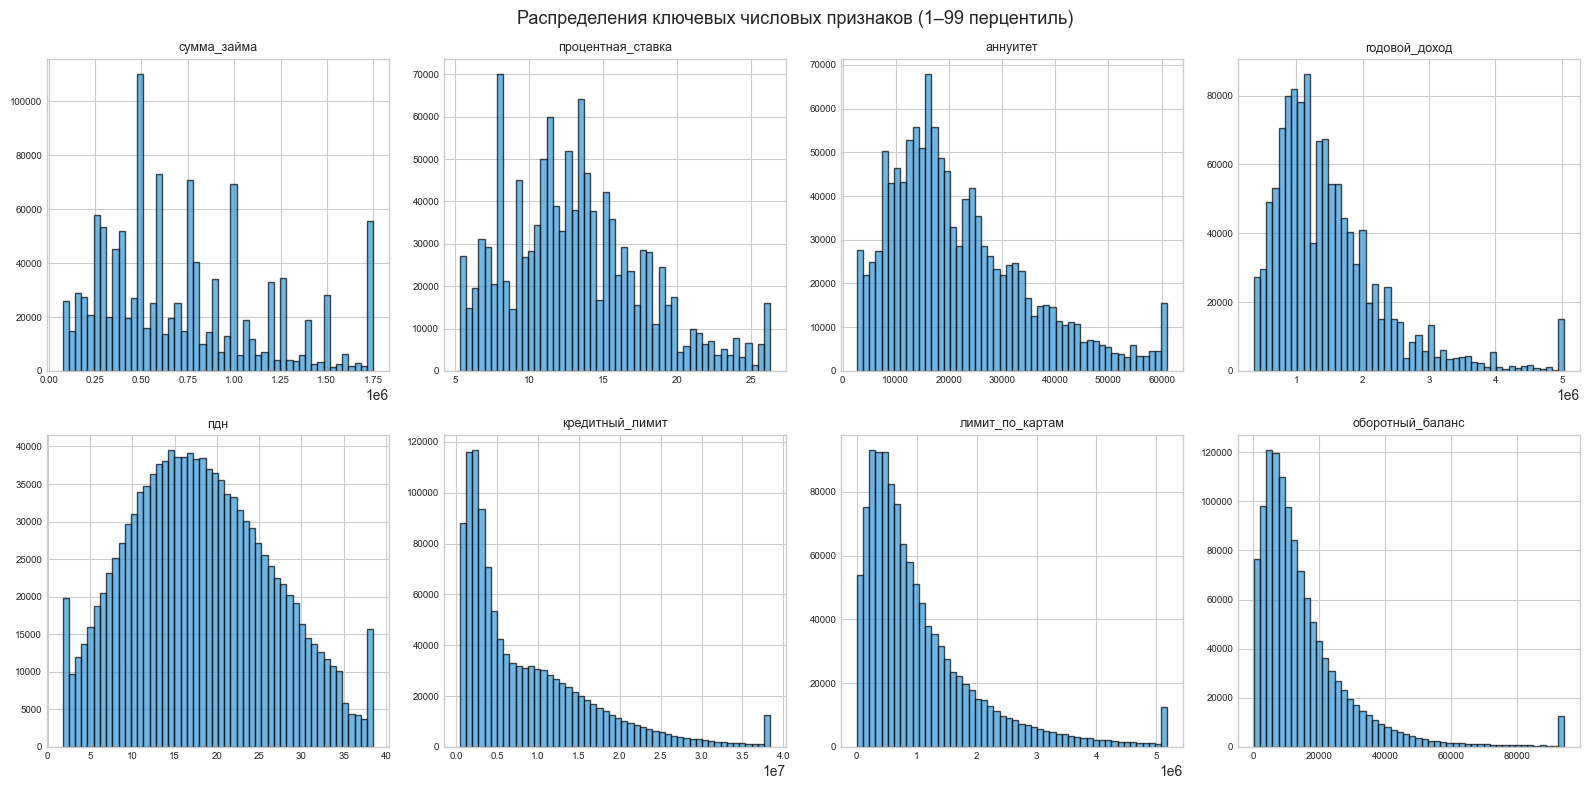

In [6]:
top_num = ['сумма_займа', 'процентная_ставка', 'аннуитет', 'годовой_доход',
           'пдн', 'кредитный_лимит', 'лимит_по_картам', 'оборотный_баланс']
top_num = [c for c in top_num if c in train.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(top_num):
    ax = axes[i // 4, i % 4]
    vals = train[col].dropna()
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    vals.clip(lower=lo, upper=hi).hist(bins=50, ax=ax, alpha=0.7, color='#3498db', edgecolor='black')
    ax.set_title(col[:30], fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Распределения ключевых числовых признаков (1–99 перцентиль)', fontsize=13)
plt.tight_layout()
plt.show()

## Распределения ключевых числовых признаков

Для набора ключевых числовых признаков были построены распределения значений с ограничением диапазона **1–99 перцентилями**.  


## Характер распределений числовых признаков

Анализ распределений показывает, что большинство финансовых признаков обладают следующими свойствами:

- выраженная **правосторонняя асимметрия** (long tail);
- наличие выбросов и экстремальных значений;
- ненормальное распределение.


## Интерпретация ключевых признаков

- **Сумма займа, кредитные лимиты, обороты** имеют длинный правый хвост, что отражает наличие небольшого числа клиентов с очень крупными финансовыми объёмами.
- **Процентная ставка** распределена более компактно, но также демонстрирует неоднородность по сегментам клиентов.
- **Аннуитет и годовой доход** показывают асимметричное распределение, типичное для платёжных и доходных показателей.
- **ПДН (показатель долговой нагрузки)** имеет сглаженное распределение с максимумом в среднем диапазоне.

## Следствия для preprocessing и моделирования

Полученные распределения повлияли на дальнейшие решения при построении моделей:

- не применялась жёсткая нормализация или стандартизация признаков;
- не использовались логарифмические преобразования в явном виде;



Топ-20 признаков по |корреляции| с таргетом:
   1. процентная_ставка                                       0.2583
   2. совокупный_пдн_заемщиков                                0.1405
   3. сумма_выплат_по_просрочкам                              0.1404
   4. нижний_порог_рейтинга_заемщика                          0.1307
   5. верхний_порог_рейтинга_заемщика                         0.1307
   6. кол-во_открытых_счетов_за_2_года                        0.1004
   7. совокупный_доход_заемщиков                              0.0901
   8. соотношение_баланса_к_лимиту_общее                      0.0888
   9. кол-во_счетов_за_посл_год                               0.0861
  10. пдн                                                     0.0840
  11. кол-во_возоб_счетов_за_2_года                           0.0825
  12. суммарная_доступная_сумма_займа_по_картам               0.0817
  13. средний_баланс_текущих_счетов                           0.0786
  14. кредитный_лимит                                     

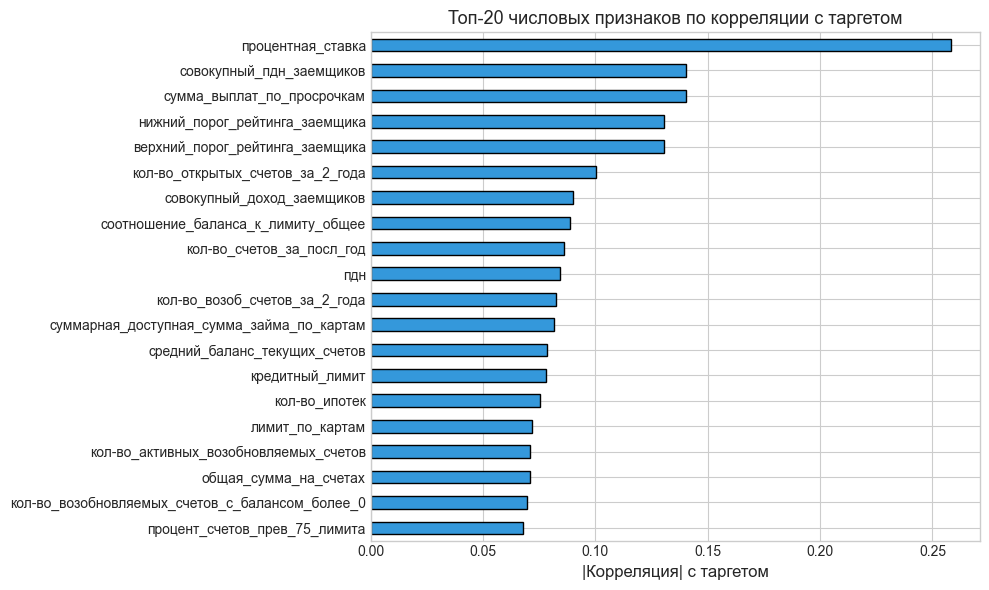

In [7]:
corrs = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

print("Топ-20 признаков по |корреляции| с таргетом:")
for i, (feat, val) in enumerate(corrs.head(20).items()):
    print(f"  {i+1:2d}. {feat:55s} {val:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
corrs.head(20).plot.barh(ax=ax, color='#3498db', edgecolor='black')
ax.set_xlabel('|Корреляция| с таргетом', fontsize=12)
ax.set_title('Топ-20 числовых признаков по корреляции с таргетом', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Корреляция числовых признаков с целевой переменной

Для числовых признаков была рассчитана абсолютная корреляция с целевой переменной `итоговый_статус_займа`.  
Анализ проводился с целью выявления наиболее линейно связанных с дефолтом признаков и общего понимания силы индивидуальных сигналов.

## Анализ силы индивидуальных признаков

Анализ топ-20 признаков по модулю корреляции показывает:

- максимальные значения корреляции находятся в диапазоне **0.25-0.07**;
- отсутствуют признаки с сильной линейной зависимостью от целевой переменной;
- вклад каждого отдельного признака в объяснение таргета является **умеренным**.


## Интерпретация наиболее коррелирующих признаков

Среди наиболее значимых признаков можно выделить несколько логических групп:

- **процентная ставка** — отражает уровень риска, заложенный при выдаче займа;
- агрегированные показатели по займам и счетам заемщика;
- показатели долговой нагрузки и использования кредитных лимитов;
- признаки, связанные с историей просрочек и активностью счетов.


## 3. Препроцессинг и Feature Engineering

In [ ]:

train['_is_train'] = 1
test['_is_train'] = 0
if TARGET not in test.columns:
    test[TARGET] = -1

data = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Общий датасет: {data.shape}")

single_val_cols = [c for c in data.columns
                   if data[c].nunique() <= 1 and c not in [ID_COL, TARGET, '_is_train']]
print(f"\nКолонки с ≤1 уникальным значением (удаляем): {single_val_cols}")

all_null_cols = [c for c in data.columns if data[c].isnull().all()]
print(f"Колонки со 100% пропусков (удаляем): {all_null_cols}")

high_card_cols = [c for c in data.select_dtypes(include='object').columns
                  if data[c].nunique() > 10000]
print(f"Колонки с ультравысокой кардинальностью (удаляем): {high_card_cols}")

drop_cols = list(set(single_val_cols + all_null_cols + high_card_cols))
data.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f"\nУдалено {len(drop_cols)} колонок. Осталось: {data.shape[1]}")

if 'дата_первого_займа' in data.columns:
    def parse_date_feature(x):
        if pd.isna(x) or '-' not in str(x):
            return np.nan, np.nan
        parts = str(x).split('-')
        return int(parts[0]), int(parts[1])

    parsed = data['дата_первого_займа'].apply(parse_date_feature)
    data['первый_займ_месяц'] = parsed.apply(lambda x: x[0])
    data['первый_займ_год'] = parsed.apply(lambda x: x[1])
    data['месяцев_с_первого_займа'] = (
        (2026 - data['первый_займ_год']) * 12 + (1 - data['первый_займ_месяц'])
    )
    data.drop(columns=['дата_первого_займа'], inplace=True)
    print("\nДата первого займа → 3 числовых признака (месяц, год, месяцев_с)")

cat_cols_final = data.select_dtypes(include='object').columns.tolist()
cat_cols_final = [c for c in cat_cols_final if c not in [ID_COL]]

label_encoders = {}
for col in cat_cols_final:
    le = LabelEncoder()
    data[col] = data[col].astype(str)
    le.fit(data[col])
    data[col] = le.transform(data[col])
    label_encoders[col] = le

print(f"\nЗакодировано {len(cat_cols_final)} категориальных признаков:")
for c in cat_cols_final:
    print(f"  • {c}")

feature_cols = [c for c in data.columns if c not in [ID_COL, TARGET, '_is_train']]

X_train = data[data['_is_train'] == 1][feature_cols].values
X_test = data[data['_is_train'] == 0][feature_cols].values
y_train = data[data['_is_train'] == 1][TARGET].values.astype(int)

print(f"\n{'='*60}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Всего признаков: {len(feature_cols)}")
print(f"{'='*60}")

Общий датасет: (1345310, 110)

Колонки с ≤1 уникальным значением (удаляем): ['платежный_график', 'коэфф_невыплаченного_сумм_остатка', 'непогашенная_сумма_из_тела_займов', 'дата_следующей_выплаты', 'код_политики', 'особая_ситуация']
Колонки со 100% пропусков (удаляем): ['дата_следующей_выплаты']
Колонки с ультравысокой кардинальностью (удаляем): ['профессия_заемщика']

Удалено 7 колонок. Осталось: 103

Дата первого займа → 3 числовых признака (месяц, год, месяцев_с)

Закодировано 15 категориальных признаков:
  • срок_займа
  • рейтинг
  • допрейтинг
  • стаж
  • владение_жильем
  • подтвержден_ли_доход
  • цель_займа
  • регион
  • пос_стоп_фактор
  • юридический_статус
  • первоначальный_статус_займа
  • пени_за_дефолт
  • тип_займа
  • совокупный_статус_подтверждения_доходов_заемщиков
  • тип_предоставления_кредита

X_train: (1210779, 102)
X_test:  (134531, 102)
Всего признаков: 102


### Объединение train и test

Для обеспечения идентичной обработки признаков обучающая и тестовая выборки были временно объединены в единый датасет.

- Добавлен служебный флаг `_is_train` для последующего корректного разделения данных.
- В тестовой выборке целевая переменная отсутствует, поэтому она была заполнена фиктивным значением.

### Удаление неинформативных признаков

- признаки с **≤ 1 уникальным значением**, не несущие полезной информации;
- признаки со **100% пропусков**, не содержащие данных;
- категориальные признаки с **ультравысокой кардинальностью** (более 10 000 уникальных значений).

Последняя группа признаков, в частности `профессия_заемщика`, была исключена как потенциальный источник шума и переобучения при отсутствии дополнительной агрегации.

### Обработка даты первого займа

Признак `дата_первого_займа` был преобразован в набор числовых признаков:

- месяц первого займа;
- год первого займа;
- количество месяцев с момента первого займа до текущего момента.
Модель будет учитывать временной контекст кредитной истории и предпочтительнее прямого использования строкового формата даты.

### Кодирование категориальных признаков

Оставшиеся категориальные признаки были закодированы с помощью `LabelEncoder`.


### Формирование обучающей и тестовой выборок

После завершения preprocessing датасет был разделён обратно на обучающую и тестовую части.


## 4. Обучение моделей (K-Fold Stratified Cross-Validation)


В качестве основной модели выбран **LightGBM (градиентный бустинг по деревьям)**, так как:
- показывает высокое качество на табличных данных;
- эффективно обучается на больших выборках (миллионы строк);
- устойчив к разным масштабам признаков и выбросам;
- хорошо работает с большим количеством признаков без ручного feature scaling.
### Стратегия валидации
Используется **Stratified K-Fold (5 фолдов)**:
- сохраняем пропорции классов на каждом разбиении;
- позволяет получить устойчивую оценку качества и снизить риск переобучения;
- обеспечивает OOF-предсказания для последующего ансамблирования.

### Параметры модели
- `learning_rate=0.05` и `n_estimators=3000` + **early stopping** позволяют находить оптимальное число деревьев без ручного подбора
- `subsample` и `colsample_bytree` добавляют стохастичность 
- `reg_alpha` и `reg_lambda` вводят регуляризацию
- `num_leaves=63`, `min_child_samples=50` задаем умеренную сложность деревьев 

In [ ]:

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_estimators': 3000,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb = np.zeros(len(X_train))
test_preds_lgb = np.zeros(len(X_test))
lgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'='*50} Fold {fold+1}/{N_FOLDS} {'='*50}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(150, verbose=True),
            lgb.log_evaluation(500),
        ]
    )

    oof_lgb[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds_lgb += model.predict_proba(X_test)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    lgb_scores.append(fold_auc)
    print(f"  → Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

oof_auc_lgb = roc_auc_score(y_train, oof_lgb)
print(f"\n{'='*60}")
print(f"  LightGBM OOF ROC-AUC: {oof_auc_lgb:.6f}")
print(f"  По фолдам: {[f'{s:.6f}' for s in lgb_scores]}")
print(f"  Среднее ± std: {np.mean(lgb_scores):.6f} ± {np.std(lgb_scores):.6f}")
print(f"{'='*60}")


================================================== Fold 1/5 ==================================================
Training until validation scores don't improve for 150 rounds
[500]	valid_0's auc: 0.886783
Early stopping, best iteration is:
[808]	valid_0's auc: 0.88701
  → Fold 1 ROC-AUC: 0.887010

================================================== Fold 2/5 ==================================================
Training until validation scores don't improve for 150 rounds
[500]	valid_0's auc: 0.887251
Early stopping, best iteration is:
[835]	valid_0's auc: 0.887509
  → Fold 2 ROC-AUC: 0.887509

================================================== Fold 3/5 ==================================================
Training until validation scores don't improve for 150 rounds
[500]	valid_0's auc: 0.887649
[1000]	valid_0's auc: 0.88794
Early stopping, best iteration is:
[1071]	valid_0's auc: 0.887958
  → Fold 3 ROC-AUC: 0.887958

================================================== Fold 4/5 ===============


### Интерпретация
- Низкое стандартное отклонение между фолдами указывает на **стабильность качества** и отсутствие выраженных проблем с отдельными сегментами данных.
- Модель демонстрирует **устойчивое обобщение** и не показывает признаков сильного переобучения.
- Early stopping (лучшие итерации ~800–1100) подтверждает, что оптимальная сложность модели достигается раньше заданного максимума `n_estimators`.

Далее полученные OOF-предсказания используются как базовый уровень и компонент для ансамблей/stacking.

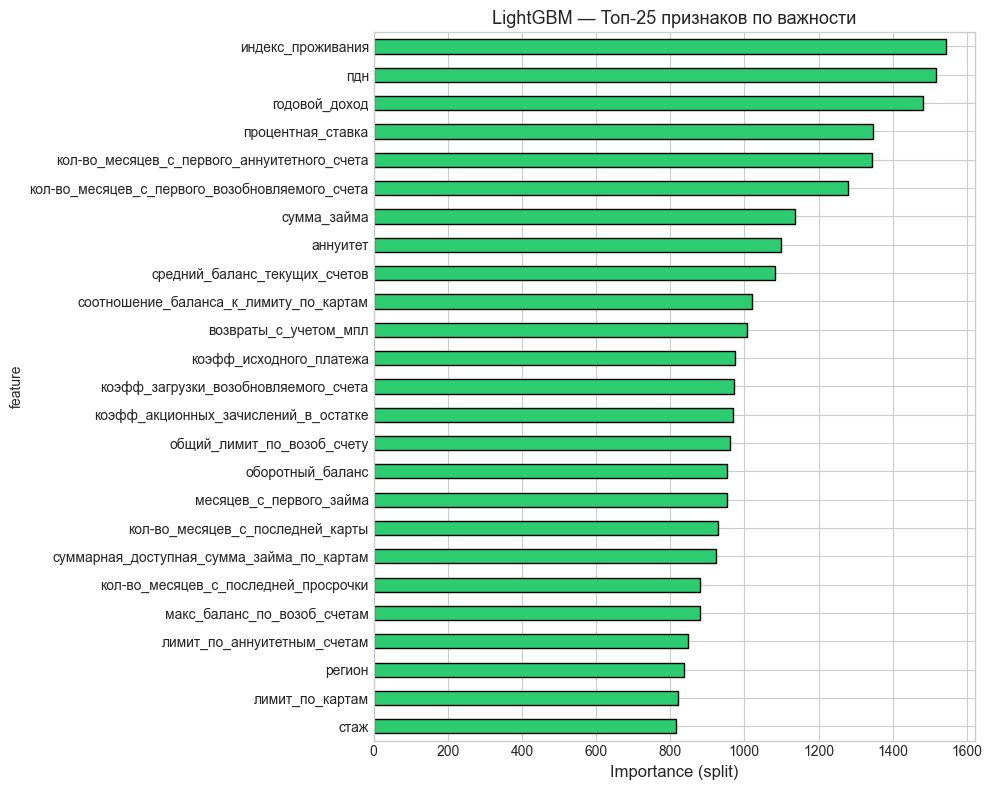

In [ ]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(25).plot.barh(x='feature', y='importance', ax=ax,
                             color='#2ecc71', edgecolor='black', legend=False)
ax.set_xlabel('Importance (split)', fontsize=12)
ax.set_title('LightGBM — Топ-25 признаков по важности', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Обучение CatBoost с 5-Fold Stratified Cross-Validation

В качестве альтернативной базовой модели был использован **CatBoost** - градиентный бустинг, специально оптимизированный для работы с категориальными признаками.

Использование CatBoost позволяет:
- проверить устойчивость решения к выбору модели;
- получить дополнительный, комплементарный источник сигналов для ансамблирования;
- снизить зависимость результата от особенностей конкретного алгоритма.

In [ ]:

cb_params = {
    'iterations': 3000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'eval_metric': 'AUC',
    'random_seed': SEED,
    'verbose': 500,
    'early_stopping_rounds': 150,
    'task_type': 'CPU',
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
}

oof_cb = np.zeros(len(X_train))
test_preds_cb = np.zeros(len(X_test))
cb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'='*50} Fold {fold+1}/{N_FOLDS} {'='*50}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model_cb = cb.CatBoostClassifier(**cb_params)
    model_cb.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    oof_cb[val_idx] = model_cb.predict_proba(X_val)[:, 1]
    test_preds_cb += model_cb.predict_proba(X_test)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_cb[val_idx])
    cb_scores.append(fold_auc)
    print(f"  → Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

oof_auc_cb = roc_auc_score(y_train, oof_cb)
print(f"\n{'='*60}")
print(f"  CatBoost OOF ROC-AUC: {oof_auc_cb:.6f}")
print(f"  По фолдам: {[f'{s:.6f}' for s in cb_scores]}")
print(f"  Среднее ± std: {np.mean(cb_scores):.6f} ± {np.std(cb_scores):.6f}")
print(f"{'='*60}")


================================================== Fold 1/5 ==================================================
0:	test: 0.8527195	best: 0.8527195 (0)	total: 361ms	remaining: 18m 1s
500:	test: 0.8841117	best: 0.8841117 (500)	total: 1m 41s	remaining: 8m 26s
1000:	test: 0.8856158	best: 0.8856158 (999)	total: 3m 18s	remaining: 6m 37s
1500:	test: 0.8863007	best: 0.8863007 (1500)	total: 5m	remaining: 4m 59s
2000:	test: 0.8866762	best: 0.8866762 (2000)	total: 6m 44s	remaining: 3m 22s
2500:	test: 0.8869132	best: 0.8869138 (2492)	total: 8m 19s	remaining: 1m 39s
2999:	test: 0.8870551	best: 0.8870559 (2996)	total: 9m 55s	remaining: 0us

bestTest = 0.8870558906
bestIteration = 2996

Shrink model to first 2997 iterations.
  → Fold 1 ROC-AUC: 0.887056

================================================== Fold 2/5 ==================================================
0:	test: 0.8533644	best: 0.8533644 (0)	total: 232ms	remaining: 11m 35s
500:	test: 0.8844176	best: 0.8844176 (500)	total: 2m 5s	remaining: 1

### Интерпретация

- Качество CatBoost сопоставимо с LightGBM, при этом стандартное отклонение между фолдами немного ниже.
Это указывает на **стабильное обобщение** модели и отсутствие выраженного переобучения.
- Незначительное отставание от LightGBM по среднему ROC-AUC компенсируется тем, что CatBoost улавливает иные нелинейные зависимости в данных.

## 5. Дополнительные модели Level-1 (для стекинга)


Помимо основных бустинговых моделей (LightGBM и CatBoost), в решение были добавлены дополнительные модели Level-1:

- **Logistic Regression (L2)**
- **ExtraTreesClassifier**

Их основная цель - не максимизация индивидуального качества, а **создать разнообразие** в ансамбле.

### Logistic Regression (L2)
- хорошо выявляет линейные зависимости;
- служит сильным базовым ориентиром.


### ExtraTreesClassifier
Ключевые особенности модели:
- высокая стохастичность;
- меньшая склонность к переобучению
- принципиально иной механизм построения деревьев по сравнению с градиентным бустингом.

Модель уступает бустингам по индивидуальному качеству, однако способна:
- улавливать альтернативные нелинейные зависимости
- снижать корреляцию ошибок между моделями в ансамбле.

In [ ]:

print("=" * 60)
print("5.1. LogisticRegression (L2)")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(np.nan_to_num(X_train, nan=0.0))
X_test_scaled = scaler.transform(np.nan_to_num(X_test, nan=0.0))

oof_logreg = np.zeros(len(X_train))
test_preds_logreg = np.zeros(len(X_test))
logreg_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'='*50} Fold {fold+1}/{N_FOLDS} {'='*50}")

    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model_lr = LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        random_state=SEED,
        n_jobs=-1,
    )
    model_lr.fit(X_tr, y_tr)

    oof_logreg[val_idx] = model_lr.predict_proba(X_val)[:, 1]
    test_preds_logreg += model_lr.predict_proba(X_test_scaled)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_logreg[val_idx])
    logreg_scores.append(fold_auc)
    print(f"  -> Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

oof_auc_logreg = roc_auc_score(y_train, oof_logreg)
print(f"\n{'='*60}")
print(f"  LogReg OOF ROC-AUC: {oof_auc_logreg:.6f}")
print(f"  По фолдам: {[f'{s:.6f}' for s in logreg_scores]}")
print(f"  Среднее +/- std: {np.mean(logreg_scores):.6f} +/- {np.std(logreg_scores):.6f}")
print(f"{'='*60}")

print("\n")
print("=" * 60)
print("5.2. ExtraTreesClassifier")
print("=" * 60)

X_train_clean = np.nan_to_num(X_train, nan=0.0)
X_test_clean = np.nan_to_num(X_test, nan=0.0)

oof_et = np.zeros(len(X_train))
test_preds_et = np.zeros(len(X_test))
et_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'='*50} Fold {fold+1}/{N_FOLDS} {'='*50}")

    X_tr, X_val = X_train_clean[train_idx], X_train_clean[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model_et = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=50,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1,
    )
    model_et.fit(X_tr, y_tr)

    oof_et[val_idx] = model_et.predict_proba(X_val)[:, 1]
    test_preds_et += model_et.predict_proba(X_test_clean)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_et[val_idx])
    et_scores.append(fold_auc)
    print(f"  -> Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

oof_auc_et = roc_auc_score(y_train, oof_et)
print(f"\n{'='*60}")
print(f"  ExtraTrees OOF ROC-AUC: {oof_auc_et:.6f}")
print(f"  По фолдам: {[f'{s:.6f}' for s in et_scores]}")
print(f"  Среднее +/- std: {np.mean(et_scores):.6f} +/- {np.std(et_scores):.6f}")
print(f"{'='*60}")

print("\n" + "=" * 60)
print("ВСЕ МОДЕЛИ LEVEL-1 (OOF ROC-AUC)")
print("=" * 60)
print(f"  LightGBM:      {oof_auc_lgb:.6f}")
print(f"  CatBoost:      {oof_auc_cb:.6f}")
print(f"  LogReg (L2):   {oof_auc_logreg:.6f}")
print(f"  ExtraTrees:    {oof_auc_et:.6f}")
print("=" * 60)

5.1. LogisticRegression (L2)

================================================== Fold 1/5 ==================================================
  -> Fold 1 ROC-AUC: 0.767479

================================================== Fold 2/5 ==================================================
  -> Fold 2 ROC-AUC: 0.770143

================================================== Fold 3/5 ==================================================
  -> Fold 3 ROC-AUC: 0.770143

================================================== Fold 4/5 ==================================================
  -> Fold 4 ROC-AUC: 0.768900

================================================== Fold 5/5 ==================================================
  -> Fold 5 ROC-AUC: 0.770135

  LogReg OOF ROC-AUC: 0.769359
  По фолдам: ['0.767479', '0.770143', '0.770143', '0.768900', '0.770135']
  Среднее +/- std: 0.769360 +/- 0.001056


5.2. ExtraTreesClassifier

================================================== Fold 1/5 =========================

## 6. Stacking: мета-признаки и мета-модель (Level-2)

**Идея стекинга:**
OOF-предсказания Level-1 моделей становятся признаками для Level-2 мета-модели.
Это позволяет мета-модели выучить, когда какая базовая модель ошибается, и оптимально комбинировать их.


## Meta-модель: LightGBM с ограниченной сложностью

В качестве мета-модели используется **LightGBM с небольшой глубиной деревьев**, что является осознанным решением.
- **max_depth ≤ 3** и `num_leaves = 7` - строгий контроль сложности;
- усиленная L1/L2-регуляризация;
- небольшое число признаков (8), что снижает риск переобучения.


In [ ]:

oof_preds_all = np.column_stack([
    oof_lgb,
    oof_cb,
    oof_logreg,
    oof_et,
])

test_preds_all = np.column_stack([
    test_preds_lgb,
    test_preds_cb,
    test_preds_logreg,
    test_preds_et,
])


meta_mean_train = oof_preds_all.mean(axis=1).reshape(-1, 1)
meta_std_train = oof_preds_all.std(axis=1).reshape(-1, 1)
meta_min_train = oof_preds_all.min(axis=1).reshape(-1, 1)
meta_max_train = oof_preds_all.max(axis=1).reshape(-1, 1)

meta_mean_test = test_preds_all.mean(axis=1).reshape(-1, 1)
meta_std_test = test_preds_all.std(axis=1).reshape(-1, 1)
meta_min_test = test_preds_all.min(axis=1).reshape(-1, 1)
meta_max_test = test_preds_all.max(axis=1).reshape(-1, 1)

X_meta_train = np.hstack([
    oof_preds_all,
    meta_mean_train, meta_std_train, meta_min_train, meta_max_train,
])
X_meta_test = np.hstack([
    test_preds_all,
    meta_mean_test, meta_std_test, meta_min_test, meta_max_test,
])

print(f"X_meta_train shape: {X_meta_train.shape}")
print(f"X_meta_test  shape: {X_meta_test.shape}")
print(f"Meta-признаки: 4 OOF + mean/std/min/max = 8 признаков")

meta_lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 7,       
    'max_depth': 3,
    'min_child_samples': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'n_estimators': 1000,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1,
}

oof_meta = np.zeros(len(X_meta_train))
test_preds_meta = np.zeros(len(X_meta_test))
meta_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta_train, y_train)):
    print(f"\nMeta Fold {fold+1}/{N_FOLDS}")

    X_tr = X_meta_train[train_idx]
    X_val = X_meta_train[val_idx]
    y_tr = y_train[train_idx]
    y_val = y_train[val_idx]

    meta_model = lgb.LGBMClassifier(**meta_lgb_params)
    meta_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ]
    )

    oof_meta[val_idx] = meta_model.predict_proba(X_val)[:, 1]
    test_preds_meta += meta_model.predict_proba(X_meta_test)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_meta[val_idx])
    meta_scores.append(fold_auc)
    print(f"  -> Meta Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

oof_auc_meta = roc_auc_score(y_train, oof_meta)
print(f"\n{'='*60}")
print(f"  Stacking Meta-Model OOF ROC-AUC: {oof_auc_meta:.6f}")
print(f"  По фолдам: {[f'{s:.6f}' for s in meta_scores]}")
print(f"  Среднее +/- std: {np.mean(meta_scores):.6f} +/- {np.std(meta_scores):.6f}")
print(f"{'='*60}")

best_w, best_auc = 0.5, 0.0
for w in np.arange(0.0, 1.01, 0.05):
    oof_mix = w * oof_lgb + (1 - w) * oof_cb
    auc_mix = roc_auc_score(y_train, oof_mix)
    if auc_mix > best_auc:
        best_auc = auc_mix
        best_w = w

oof_ensemble = best_w * oof_lgb + (1 - best_w) * oof_cb
test_ensemble = best_w * test_preds_lgb + (1 - best_w) * test_preds_cb
oof_auc_ensemble = roc_auc_score(y_train, oof_ensemble)


print("\n" + "=" * 60)
print("СРАВНЕНИЕ ПОДХОДОВ (OOF ROC-AUC)")
print("=" * 60)
print(f"  LightGBM (best base):       {oof_auc_lgb:.6f}")
print(f"  CatBoost:                   {oof_auc_cb:.6f}")
print(f"  LogReg (L2):                {oof_auc_logreg:.6f}")
print(f"  ExtraTrees:                 {oof_auc_et:.6f}")
print(f"  Simple Ensemble (w={best_w:.2f}):  {oof_auc_ensemble:.6f}")
print(f"  Stacking Meta-Model:        {oof_auc_meta:.6f}")
print("=" * 60)

X_meta_train shape: (1210779, 8)
X_meta_test  shape: (134531, 8)
Meta-признаки: 4 OOF + mean/std/min/max = 8 признаков

Meta Fold 1/5
  -> Meta Fold 1 ROC-AUC: 0.887821

Meta Fold 2/5
  -> Meta Fold 2 ROC-AUC: 0.888223

Meta Fold 3/5
  -> Meta Fold 3 ROC-AUC: 0.888683

Meta Fold 4/5
  -> Meta Fold 4 ROC-AUC: 0.887533

Meta Fold 5/5
  -> Meta Fold 5 ROC-AUC: 0.888872

  Stacking Meta-Model OOF ROC-AUC: 0.888209
  По фолдам: ['0.887821', '0.888223', '0.888683', '0.887533', '0.888872']
  Среднее +/- std: 0.888226 +/- 0.000504

СРАВНЕНИЕ ПОДХОДОВ (OOF ROC-AUC)
  LightGBM (best base):       0.887575
  CatBoost:                   0.887241
  LogReg (L2):                0.769359
  ExtraTrees:                 0.859239
  Simple Ensemble (w=0.55):  0.887957
  Stacking Meta-Model:        0.888209


## 7. Pseudo-labeling (осторожный эксперимент)

**Идея:** используем предсказания стекинг-модели на тесте, чтобы найти объекты, в которых модель "уверена" (proba >= 0.98 или <= 0.02). Добавляем их в обучающую выборку с пониженным весом.

**осторожный порог**
1. Минимизируем риск "отравления" - добавляем только те объекты, где модель практически не сомневается
2. Избегаем confirmation bias - модель не "подтверждает" свои же ошибки на неуверенных примерах
3. С пониженным весом (0.3) pseudo-labels не доминируют над реальными данными


In [ ]:
CONFIDENT_HIGH = 0.98   
CONFIDENT_LOW = 0.02    
PL_WEIGHT = 0.3         

confident_mask = (test_preds_meta >= CONFIDENT_HIGH) | (test_preds_meta <= CONFIDENT_LOW)
pseudo_labels = (test_preds_meta >= 0.5).astype(int)

n_pseudo = confident_mask.sum()
n_pseudo_pos = (pseudo_labels[confident_mask] == 1).sum()
n_pseudo_neg = (pseudo_labels[confident_mask] == 0).sum()

print("=" * 60)
print("PSEUDO-LABELING")
print("=" * 60)
print(f"  Порог уверенности: [{CONFIDENT_LOW}, {CONFIDENT_HIGH}]")
print(f"  Отобрано объектов: {n_pseudo} из {len(test_preds_meta)} ({100*n_pseudo/len(test_preds_meta):.1f}%)")
print(f"  Из них: позитивных = {n_pseudo_pos}, негативных = {n_pseudo_neg}")
print(f"  Вес pseudo-labels: {PL_WEIGHT}")

if n_pseudo > 0:
    
    X_pseudo = X_meta_test[confident_mask]
    y_pseudo = pseudo_labels[confident_mask]

    oof_pl = np.zeros(len(X_meta_train))
    test_preds_pl = np.zeros(len(X_meta_test))
    pl_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta_train, y_train)):
        print(f"\n  PL Meta Fold {fold+1}/{N_FOLDS}")

        X_tr_real = X_meta_train[train_idx]
        y_tr_real = y_train[train_idx]
        w_tr_real = np.ones(len(X_tr_real))

        X_tr_combined = np.vstack([X_tr_real, X_pseudo])
        y_tr_combined = np.concatenate([y_tr_real, y_pseudo])
        w_tr_combined = np.concatenate([w_tr_real, np.full(len(X_pseudo), PL_WEIGHT)])

        X_val = X_meta_train[val_idx]
        y_val = y_train[val_idx]

        pl_model = lgb.LGBMClassifier(**meta_lgb_params)
        pl_model.fit(
            X_tr_combined, y_tr_combined,
            sample_weight=w_tr_combined,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0),
            ]
        )

        oof_pl[val_idx] = pl_model.predict_proba(X_val)[:, 1]
        test_preds_pl += pl_model.predict_proba(X_meta_test)[:, 1] / N_FOLDS

        fold_auc = roc_auc_score(y_val, oof_pl[val_idx])
        pl_scores.append(fold_auc)
        print(f"    -> Fold {fold+1} ROC-AUC: {fold_auc:.6f}")

    oof_auc_pl = roc_auc_score(y_train, oof_pl)
    print(f"\n{'='*60}")
    print(f"  Stacking + PseudoLabeling OOF ROC-AUC: {oof_auc_pl:.6f}")
    print(f"  По фолдам: {[f'{s:.6f}' for s in pl_scores]}")
    print(f"  Среднее +/- std: {np.mean(pl_scores):.6f} +/- {np.std(pl_scores):.6f}")
    print(f"{'='*60}")

    pl_improved = oof_auc_pl > oof_auc_meta
    if pl_improved:
        print(f"\n  [OK] Pseudo-labeling УЛУЧШИЛ OOF: {oof_auc_meta:.6f} -> {oof_auc_pl:.6f} (+{oof_auc_pl - oof_auc_meta:.6f})")
    else:
        print(f"\n  [X] Pseudo-labeling НЕ улучшил OOF: {oof_auc_meta:.6f} -> {oof_auc_pl:.6f} ({oof_auc_pl - oof_auc_meta:.6f})")
        print("    -> Этот эксперимент помечен как неудачный и НЕ используется в финальном submission")
else:
    print("\n  Нет уверенных объектов — pseudo-labeling пропущен")
    oof_auc_pl = 0
    test_preds_pl = test_preds_meta
    pl_improved = False

PSEUDO-LABELING
  Порог уверенности: [0.02, 0.98]
  Отобрано объектов: 3216 из 134531 (2.4%)
  Из них: позитивных = 1, негативных = 3215
  Вес pseudo-labels: 0.3

  PL Meta Fold 1/5
    -> Fold 1 ROC-AUC: 0.887828

  PL Meta Fold 2/5
    -> Fold 2 ROC-AUC: 0.888173

  PL Meta Fold 3/5
    -> Fold 3 ROC-AUC: 0.888698

  PL Meta Fold 4/5
    -> Fold 4 ROC-AUC: 0.887559

  PL Meta Fold 5/5
    -> Fold 5 ROC-AUC: 0.888879

  Stacking + PseudoLabeling OOF ROC-AUC: 0.888210
  По фолдам: ['0.887828', '0.888173', '0.888698', '0.887559', '0.888879']
  Среднее +/- std: 0.888228 +/- 0.000501

  [OK] Pseudo-labeling УЛУЧШИЛ OOF: 0.888209 -> 0.888210 (+0.000001)


## 8. Финальный выбор и формирование submission

Выбираем лучший вариант **строго по OOF ROC-AUC**:

In [ ]:
results = {
    'LightGBM':         (oof_auc_lgb, test_preds_lgb),
    'CatBoost':         (oof_auc_cb, test_preds_cb),
    'LogReg (L2)':      (oof_auc_logreg, test_preds_logreg),
    'ExtraTrees':       (oof_auc_et, test_preds_et),
    'Simple Ensemble':  (oof_auc_ensemble, test_ensemble),
    'Stacking':         (oof_auc_meta, test_preds_meta),
}

if n_pseudo > 0 and pl_improved:
    results['Stacking+PL'] = (oof_auc_pl, test_preds_pl)

print("=" * 60)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ ВАРИАНТОВ (OOF ROC-AUC)")
print("=" * 60)
for name, (auc_val, _) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"  {name:30s}: {auc_val:.6f}")
print("=" * 60)

best_name = max(results, key=lambda k: results[k][0])
best_preds = results[best_name][1]
best_oof_auc = results[best_name][0]

print(f"\n>>> Лучший вариант: {best_name} (OOF AUC = {best_oof_auc:.6f})")
print(f">>> Используется для финального submission")

# === Формируем submission.csv ===
submission = pd.DataFrame({
    'ID': test_ids,
    'Proba': best_preds
})

submission.to_csv('submission.csv', index=False)

# === Создаём submission.zip ===
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.csv')

print(f"\n{'='*60}")
print(f"submission.csv и submission.zip сохранены!")
print(f"  Строк:   {len(submission)}")
print(f"  Колонки: {list(submission.columns)}")
print(f"  Proba -- min: {submission['Proba'].min():.6f}, "
      f"max: {submission['Proba'].max():.6f}, "
      f"mean: {submission['Proba'].mean():.6f}")
print(f"{'='*60}")

# === Контрольные статистики для воспроизводимости ===
print(f"\n{'='*60}")
print("КОНТРОЛЬНЫЕ СТАТИСТИКИ")
print(f"{'='*60}")
print(f"  SEED:             {SEED}")
print(f"  N_FOLDS:          {N_FOLDS}")
print(f"  Train rows:       {len(X_train)}")
print(f"  Test rows:        {len(X_test)}")
print(f"  Features:         {X_train.shape[1]}")
print(f"  Level-1 models:   LightGBM, CatBoost, LogReg (L2), ExtraTrees")
print(f"  Meta-model:       LightGBM (depth=3)")
print(f"  Best approach:    {best_name}")
print(f"  Best OOF AUC:     {best_oof_auc:.6f}")
print(f"  Submission mean:  {submission['Proba'].mean():.6f}")
print(f"  Submission std:   {submission['Proba'].std():.6f}")
print(f"{'='*60}")

submission.head(10)

ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ ВАРИАНТОВ (OOF ROC-AUC)
  Stacking+PL                   : 0.888210
  Stacking                      : 0.888209
  Simple Ensemble               : 0.887957
  LightGBM                      : 0.887575
  CatBoost                      : 0.887241
  ExtraTrees                    : 0.859239
  LogReg (L2)                   : 0.769359

>>> Лучший вариант: Stacking+PL (OOF AUC = 0.888210)
>>> Используется для финального submission

submission.csv и submission.zip сохранены!
  Строк:   134531
  Колонки: ['ID', 'Proba']
  Proba -- min: 0.004602, max: 0.979559, mean: 0.199422

КОНТРОЛЬНЫЕ СТАТИСТИКИ
  SEED:             42
  N_FOLDS:          5
  Train rows:       1210779
  Test rows:        134531
  Features:         102
  Level-1 models:   LightGBM, CatBoost, LogReg (L2), ExtraTrees
  Meta-model:       LightGBM (depth=3)
  Best approach:    Stacking+PL
  Best OOF AUC:     0.888210
  Submission mean:  0.199422
  Submission std:   0.160527


,ID,Proba
0,85540387,0.065126
1,28112500,0.047424
2,65731570,0.101471
3,65874747,0.577784
4,57893355,0.312627
5,80589347,0.413855
6,36381174,0.081935
7,624831,0.216948
8,44065675,0.274384
9,771518,0.322504


## Итоговое сравнение (OOF ROC-AUC)

Были рассмотрены:
- базовые модели (LightGBM, CatBoost, LogReg, ExtraTrees);
- простой ансамбль (weighted average);
- stacking (meta-модель на OOF-предсказаниях);
- stacking с pseudo-labeling (если даёт улучшение).

Результаты показывают последовательное улучшение качества:
- базовые бустинги дают сильный baseline
- простой ансамбль улучшает результат за счёт комплементарности моделей
- stacking даёт дополнительный прирост за счёт адаптивного комбинирования сигналов
- pseudo-labeling используется только при подтверждённом улучшении качества.

### Финальный вывод

Наилучшее качество показал подход **Stacking + Pseudo-Labeling** (при условии улучшения OOF), что подтверждает эффективность многоуровневого ансамблирования на табличных данных.



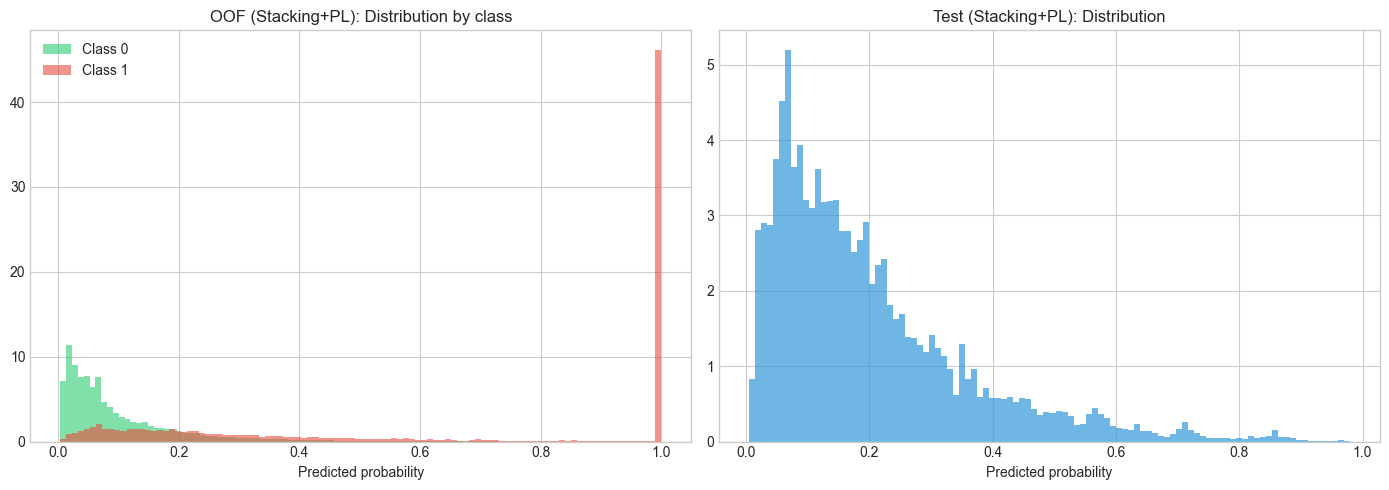

In [ ]:
oof_results = {
    'LightGBM':         oof_lgb,
    'CatBoost':         oof_cb,
    'LogReg (L2)':      oof_logreg,
    'ExtraTrees':       oof_et,
    'Simple Ensemble':  oof_ensemble,
    'Stacking':         oof_meta,
}
if n_pseudo > 0 and pl_improved:
    oof_results['Stacking+PL'] = oof_pl

best_oof = oof_results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(best_oof[y_train == 0], bins=100, alpha=0.6, label='Class 0', color='#2ecc71', density=True)
axes[0].hist(best_oof[y_train == 1], bins=100, alpha=0.6, label='Class 1', color='#e74c3c', density=True)
axes[0].set_title(f'OOF ({best_name}): Distribution by class', fontsize=12)
axes[0].set_xlabel('Predicted probability')
axes[0].legend()

axes[1].hist(best_preds, bins=100, alpha=0.7, color='#3498db', density=True)
axes[1].set_title(f'Test ({best_name}): Distribution', fontsize=12)
axes[1].set_xlabel('Predicted probability')

plt.tight_layout()
plt.show()

На левом графике показано распределение предсказанных вероятностей для обучающей выборки с разбиением по истинным классам.

- для класса **0 (нет дефолта)** большинство предсказаний сосредоточено в области низких вероятностей;
- для класса **1 (дефолт)** распределение смещено вправо, с заметной долей объектов с высокой вероятностью;


На правом графике представлено распределение вероятностей дефолта на тестовой выборке.

- форма распределения схожа с OOF-распределением;
- основная масса клиентов имеет низкий прогнозируемый риск;
- присутствует правый хвост с небольшим числом клиентов с высокой вероятностью дефолта.
